# Signal Interpolation
De-interleaves 7 signals from `Xtrain.mat`, interpolates each individually, then re-interleaves and saves to a new `.mat` file.

In [8]:
import numpy as np
import scipy.io
import scipy.interpolate
import matplotlib.pyplot as plt

## Parameters

In [9]:
INPUT_PATH = "Xtrain.mat"
N_SIGNALS = 7

# How many points to generate per original point.
SCALE_FACTOR = 2

OUTPUT_PATH = f"Xtrain_interpolated_{SCALE_FACTOR}.mat"  

# Interpolation method: 'linear', 'cubic', 'quintic'.
INTERP_KIND = "cubic"

## Load & de-interleave

In [10]:
raw = np.array(scipy.io.loadmat(INPUT_PATH)["Xtrain"]).flatten()

trimmed = len(raw) - len(raw) % N_SIGNALS
raw = raw[:trimmed]

signals = [raw[i::N_SIGNALS] for i in range(N_SIGNALS)]

print(f"Total samples after trim: {len(raw)}")
print(f"Samples per signal: {len(signals[0])}")

Total samples after trim: 994
Samples per signal: 142


## Interpolate each signal individually

In [11]:
interpolated_signals = []

for i, sig in enumerate(signals):
    n_orig = len(sig)
    x_orig = np.arange(n_orig)
    n_new  = n_orig * SCALE_FACTOR
    x_new  = np.linspace(0, n_orig - 1, n_new)

    interp_fn = scipy.interpolate.interp1d(x_orig, sig, kind=INTERP_KIND)
    sig_interp = interp_fn(x_new)

    interpolated_signals.append(sig_interp)
    print(f"Signal {i+1}: {n_orig} -> {n_new} points")

n_per_signal = len(interpolated_signals[0])
print(f"\nNew samples per signal: {n_per_signal}")

Signal 1: 142 -> 284 points
Signal 2: 142 -> 284 points
Signal 3: 142 -> 284 points
Signal 4: 142 -> 284 points
Signal 5: 142 -> 284 points
Signal 6: 142 -> 284 points
Signal 7: 142 -> 284 points

New samples per signal: 284


## Re-interleave

In [ ]:
# Stack into (N_SIGNALS, n_per_signal) then interleave along axis 0
stacked    = np.stack(interpolated_signals, axis=1)
interleaved = stacked.flatten() 

interleaved = np.clip(interleaved, raw.min(), raw.max())

print(f"Original total length: {len(raw)}")
print(f"Interpolated total length: {len(interleaved)}")

Original total length: 994
Interpolated total length: 1988


## Visual check

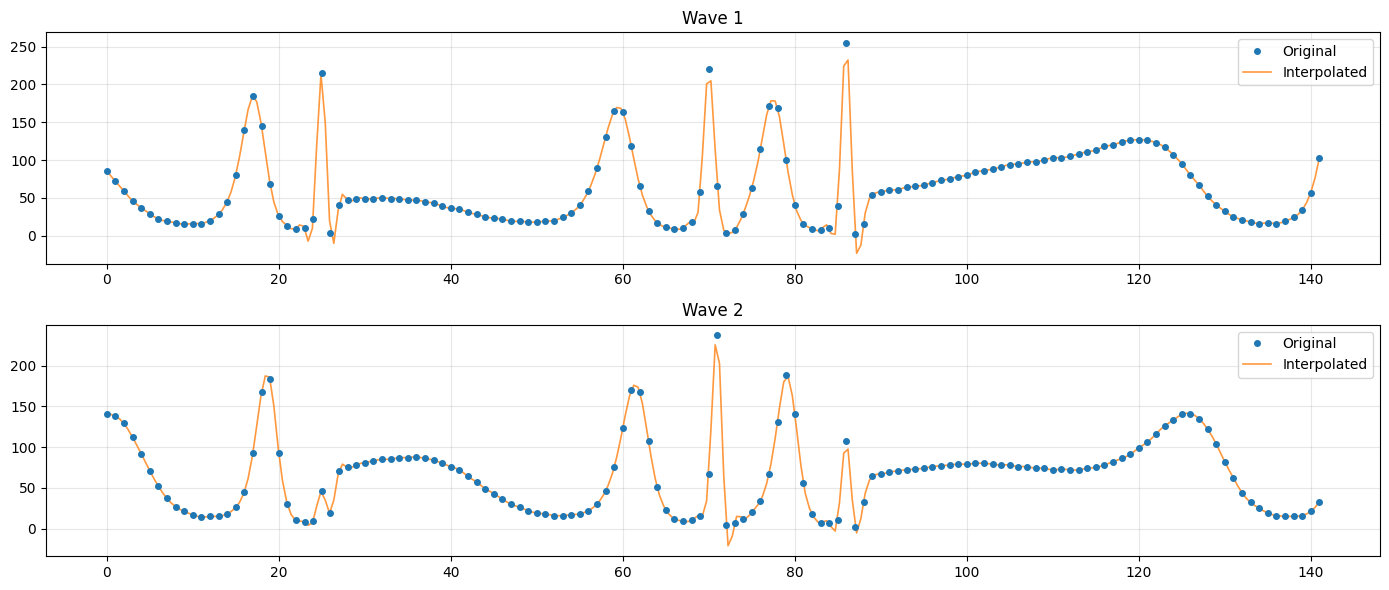

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, i in zip(axes, [0, 1]):
    x_orig = np.arange(len(signals[i]))
    x_new  = np.linspace(0, len(signals[i]) - 1, len(interpolated_signals[i]))
    ax.plot(x_orig, signals[i], "o", ms=4, label="Original", zorder=3)
    ax.plot(x_new,  interpolated_signals[i], "-", lw=1.2, label="Interpolated", alpha=0.8)
    ax.set_title(f"Wave {i+1}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save to new .mat file

In [14]:
# Reshape to (N, 1) to match the original mat file layout
Xtrain_new = interleaved.reshape(-1, 1).astype(np.float64)
scipy.io.savemat(OUTPUT_PATH, {"Xtrain": Xtrain_new})

# Verify round-trip
verify = np.array(scipy.io.loadmat(OUTPUT_PATH)["Xtrain"])
print(f"Saved shape: {verify.shape}")
print(f"Saved to: {OUTPUT_PATH}")

Saved shape: (1988, 1)
Saved to: Xtrain_interpolated_2.mat
